# ==========LOGISTIC REGRESSION===========

## 1. Import Necessary Libraries

In [1]:
import pandas as pd 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pickle import dump

# 2. Import Dataset

In [2]:
claimants_data = pd.read_csv("3. ML_Claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


# 3. Data Understanding

In [3]:
claimants_data.shape

(1340, 7)

In [4]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [6]:
claimants_data.describe

<bound method NDFrame.describe of       CASENUM  ATTORNEY  CLMSEX  CLMINSUR  SEATBELT  CLMAGE    LOSS
0           5         0     0.0       1.0       0.0    50.0  34.940
1           3         1     1.0       0.0       0.0    18.0   0.891
2          66         1     0.0       1.0       0.0     5.0   0.330
3          70         0     0.0       1.0       1.0    31.0   0.037
4          96         1     0.0       1.0       0.0    30.0   0.038
...       ...       ...     ...       ...       ...     ...     ...
1335    34100         1     0.0       1.0       0.0     NaN   0.576
1336    34110         0     1.0       1.0       0.0    46.0   3.705
1337    34113         1     1.0       1.0       0.0    39.0   0.099
1338    34145         0     1.0       0.0       0.0     8.0   3.177
1339    34153         1     1.0       1.0       0.0    30.0   0.688

[1340 rows x 7 columns]>

# 4. Data Preparation

## 4.1 Data Cleaning

In [7]:
claimants_data = claimants_data.dropna()   # Axis=0(default) - It checks row-wise and drops the NA
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [8]:
1340-1096

244

In [9]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

## 4.2 Separate your Inputs and Outputs

In [10]:
X = claimants_data.drop(labels=["CASENUM","ATTORNEY"],axis = 1)    # Axis=1 - It checks column-wise and drops 
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [11]:
# we can't predict the result(If they hire Attorney or Not) based on "CASENUM" colum(Name of the client)..so it is not necessary..so we droped it
# 'ATTORNEY' is the output column

In [12]:
Y = claimants_data["ATTORNEY"]
Y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

# 5. Model Building

## 5.1  **K-Fold** Cross Validation Test

In [13]:
from sklearn.model_selection import KFold,cross_val_score

In [32]:
kfold = KFold(n_splits=5, shuffle=True, random_state=123)

cv_scores = cross_val_score(estimator = logistic_model,X = X, y = Y, cv = kfold)

print(cv_scores)
print("Overall Accuracy = ",cv_scores.mean().round(2))
print("Standard Deviation = ",cv_scores.std().round(2))

[0.68636364 0.71232877 0.72146119 0.71689498 0.68949772]
Overall Accuracy =  0.71
Standard Deviation =  0.01


## 5.2  LOOCV

In [33]:
from sklearn.model_selection import LeaveOneOut

In [35]:
loocv = LeaveOneOut()

cv_scores = cross_val_score(estimator = logistic_model,X = X, y = Y, cv = loocv)

print(cv_scores)
print("Overall Accuracy = ",cv_scores.mean().round(2))
print("Standard Deviation = ",cv_scores.std().round(2))     # Will be Higher Standard Deviation

[1. 1. 1. ... 1. 1. 1.]
Overall Accuracy =  0.7
Standard Deviation =  0.46


## 5.2 Train-Test Split Test

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.20,shuffle=True,random_state=34)  #either test_size or train_size you can give
X_train, X_test, Y_train, Y_test

(     CLMSEX  CLMINSUR  SEATBELT  CLMAGE    LOSS
 478     0.0       1.0       1.0    10.0   1.318
 387     1.0       1.0       0.0    55.0   0.604
 47      0.0       1.0       0.0     1.0   0.000
 220     1.0       1.0       1.0     7.0   0.983
 152     1.0       1.0       0.0     6.0   0.075
 ..      ...       ...       ...     ...     ...
 731     0.0       1.0       0.0    30.0   4.014
 817     0.0       1.0       0.0    48.0   0.390
 557     0.0       1.0       0.0    30.0   0.565
 386     1.0       1.0       0.0    35.0   0.860
 599     1.0       1.0       0.0    37.0  63.361
 
 [876 rows x 5 columns],
       CLMSEX  CLMINSUR  SEATBELT  CLMAGE   LOSS
 627      1.0       1.0       0.0    40.0  6.337
 1125     1.0       1.0       0.0    37.0  4.609
 1124     1.0       1.0       0.0    46.0  0.730
 1025     1.0       1.0       0.0    38.0  3.406
 481      1.0       1.0       0.0    70.0  0.566
 ...      ...       ...       ...     ...    ...
 658      0.0       1.0       0.0    14.0 

In [16]:
X_train   # Datas Shuffle aagi vandhruku coz we use shuffle  #Unbiased sampling

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
478,0.0,1.0,1.0,10.0,1.318
387,1.0,1.0,0.0,55.0,0.604
47,0.0,1.0,0.0,1.0,0.000
220,1.0,1.0,1.0,7.0,0.983
152,1.0,1.0,0.0,6.0,0.075
...,...,...,...,...,...
731,0.0,1.0,0.0,30.0,4.014
817,0.0,1.0,0.0,48.0,0.390
557,0.0,1.0,0.0,30.0,0.565
386,1.0,1.0,0.0,35.0,0.860


In [17]:
logistic_model = LogisticRegression()

# 6. Model Training

In [18]:
logistic_model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
dt_model = DecisionTreeClassifier()

In [21]:
dt_model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# 7. Model Testing (Logistic Regression)

## Training Data

In [22]:
Y_pred_train= logistic_model.predict(X_train)
Y_pred_train

array([0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

## Testing Data

In [23]:
Y_pred_test = logistic_model.predict(X_test)
Y_pred_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0])

# 8. Model Evaluation (Logistic Regression)

In [24]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

## 8.1 Training Data's Evaluation Metrics

In [25]:
print(classification_report(y_true = Y_train, y_pred = Y_pred_train))#giving inside print makes the result ordered otherwise it will comes in inorderly

              precision    recall  f1-score   support

           0       0.75      0.66      0.70       453
           1       0.68      0.77      0.72       423

    accuracy                           0.71       876
   macro avg       0.71      0.71      0.71       876
weighted avg       0.71      0.71      0.71       876



In [26]:
print(confusion_matrix(y_true = Y_train, y_pred = Y_pred_train))

[[297 156]
 [ 99 324]]


### ROC Curve - Receiver Operating Characteristics
### AUC - Area Under this Curve
    **AUC Value**	**Model Quality**
            1.0	      Perfect model
            0.9+	      Excellent
            0.8    	      Good
            0.7	      Acceptable
            0.5	      Random guess

0.7107932929406792


Text(0, 0.5, 'True Positive Rate')

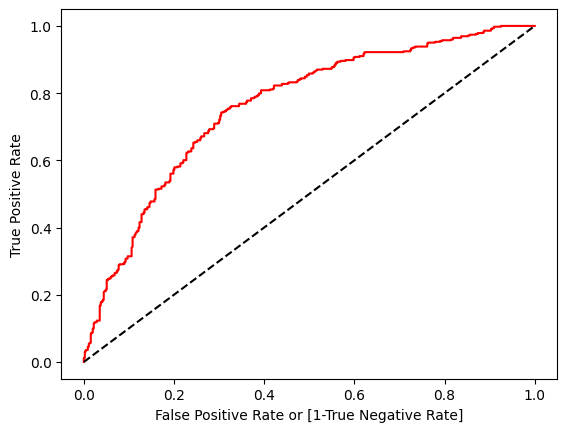

In [27]:
#class 0 = No Attorney
#class 1 = Attorney
fpr,tpr,thresholds = roc_curve(y_true = Y_train,y_score = logistic_model.predict_proba(X_train)[:,1]) #[:,1] means[rows,columns]...(:)-all rows,(1)-class1

auc = roc_auc_score(y_true = Y_train,y_score = Y_pred_train)  #gives Separability btw classes..we need maximum separability score(max=1)
print(auc)

import matplotlib.pyplot as plt     #To create graphs
plt.plot(fpr,tpr,color = 'red', label = 'logistic model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

In [28]:
accuracy_score(Y_train,Y_pred_train)

0.708904109589041

## 8.2 Test Data's Evaluation Metrics

In [29]:
print(classification_report(y_true = Y_test, y_pred = Y_pred_test))

              precision    recall  f1-score   support

           0       0.77      0.62      0.69       125
           1       0.61      0.76      0.67        95

    accuracy                           0.68       220
   macro avg       0.69      0.69      0.68       220
weighted avg       0.70      0.68      0.68       220



In [30]:
print(confusion_matrix(y_true = Y_test, y_pred = Y_pred_test))

[[78 47]
 [23 72]]


0.6909473684210526


Text(0, 0.5, 'True Positive Rate')

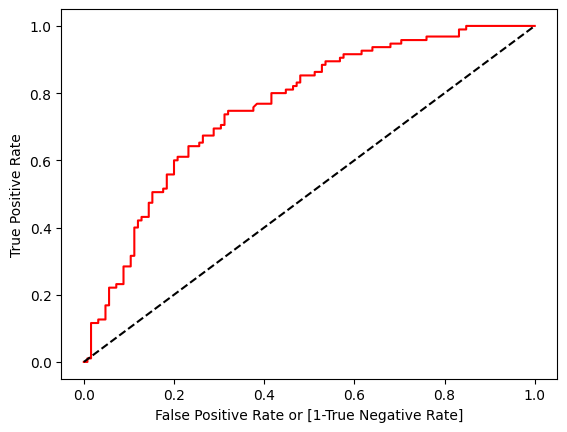

In [31]:
fpr,tpr,thresholds = roc_curve(y_true = Y_test,y_score = logistic_model.predict_proba(X_test)[:,1])

auc = roc_auc_score(y_true = Y_test,y_score = Y_pred_test)   #gives Separability btw classes..we need maximum separability score(max=1)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'logistic model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

In [32]:
accuracy_score(Y_test,Y_pred_test)

0.6818181818181818

# 9. Model Deployment

In [33]:
from pickle import dump

In [34]:
dump(logistic_model,open("claimants.pkl",mode = "wb"))

### THE END!!!

# -----------Decision Tree-----------

# Model Testing (Decision Tree)

## Training Data

In [35]:
Y_pred_train_dt= dt_model.predict(X_train)
Y_pred_train_dt

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,

## Test Data

In [36]:
Y_pred_test_dt= dt_model.predict(X_test)
Y_pred_test_dt

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0])

# 8. Model Evaluation (Decision Tree)

## 8.1 Training Data Evaluation Metrics

In [37]:
print(classification_report(y_true = Y_train, y_pred = Y_pred_train_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       453
           1       1.00      0.99      1.00       423

    accuracy                           1.00       876
   macro avg       1.00      1.00      1.00       876
weighted avg       1.00      1.00      1.00       876



In [38]:
print(confusion_matrix(y_true = Y_train, y_pred = Y_pred_train_dt))

[[453   0]
 [  4 419]]


In [39]:
accuracy_score(Y_train,Y_pred_train_dt)

0.9954337899543378

0.9952718676122931


Text(0, 0.5, 'True Positive Rate')

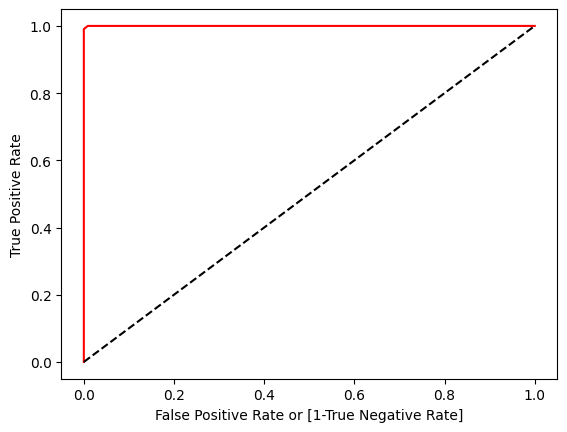

In [40]:
fpr,tpr,thresholds = roc_curve(y_true = Y_train,y_score = dt_model.predict_proba(X = X_train)[:,1])

auc = roc_auc_score(y_true = Y_train,y_score = Y_pred_train_dt)
print(auc)

from matplotlib import pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'DT model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

## 8.2 Test Data Evaluation Metrics

In [41]:
print(classification_report(y_true = Y_test, y_pred = Y_pred_test_dt))

              precision    recall  f1-score   support

           0       0.66      0.58      0.62       125
           1       0.52      0.61      0.56        95

    accuracy                           0.59       220
   macro avg       0.59      0.59      0.59       220
weighted avg       0.60      0.59      0.59       220



In [42]:
print(confusion_matrix(y_true = Y_test, y_pred = Y_pred_test_dt))

[[72 53]
 [37 58]]


In [43]:
accuracy_score(Y_test,Y_pred_test_dt)

0.5909090909090909

0.5932631578947369


Text(0, 0.5, 'True Positive Rate')

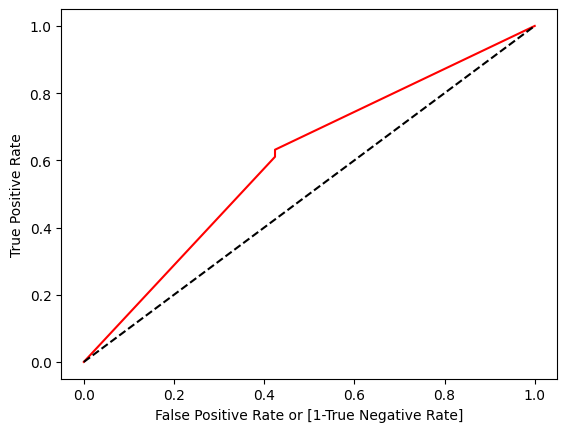

In [44]:
fpr,tpr,thresholds = roc_curve(y_true = Y_test,y_score = dt_model.predict_proba(X = X_test)[:,1])

auc = roc_auc_score(y_true = Y_test,y_score = Y_pred_test_dt)
print(auc)

from matplotlib import pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'DT model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

#### Conclusion:
   - Hey This Model got OverFitted....so this is a **OverFitting Problem**
   - We Always expect **Generalized Model**.

#### BIAS - VARIANCE

 - Training Errors/Accuracy - **BIAS**
 - Test Errors/Accuracy - **VARIANCE**

#### Model **OverFitting** - Low Bias and High Variance
#### Model **UnderFitting** - High Bias and Low Variance

#### EXPECTED MODEL -- **GENERALIZED MODEL** - Low Bias and Low Variace
So,there is always a **Tradeoff maintained between Bias and Variance**.

In [1]:
# To Overcome this overfitting problem....we have to covert this into Generalized model

# Model Training

In [61]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [72]:
dt_model = DecisionTreeClassifier(max_depth=5, criterion='gini')   #you can see below chart that 5 times the tree grew 

 # - The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure
 # - Here we set, max_depth = 5, so after that tree will not drill down even if it is impure

## Grid Search CV (Cross Validation)

 - Grid Search is a hyperparameter **tuning technique** in Machine Learning that helps to find the **best combination of hyperparameters** for a given model. It works by defining a grid of hyperparameters and then training the model with all the **possible combinations of hyperparameters** to find the best performing set.

In [73]:
from sklearn.model_selection import GridSearchCV

In [76]:
grid_search = GridSearchCV(estimator = dt_model,param_grid = {"max_depth":[5,6,7,8,9,10], 
                                                              "criterion":['gini','entropy']})
grid_search.fit(X,Y)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'gini', 'max_depth': 5}
0.7244375259443754


In [78]:
grid_search = GridSearchCV(estimator = dt_model,param_grid = {"max_depth":[5,6,7,8,9,10], 
                                                              "criterion":['gini','entropy']})
grid_search.fit(X_train,Y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5}
0.7157532467532468


In [79]:
# After getting the best hyper parameter for model...you can use that in a model like

# dt_model = DecisionTreeClassifier(max_depth=5, criterion='entropy')....to put this step only, we are using this grid search.

# using this helps us to reduce the Bias and Variace

In [47]:
dt_model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


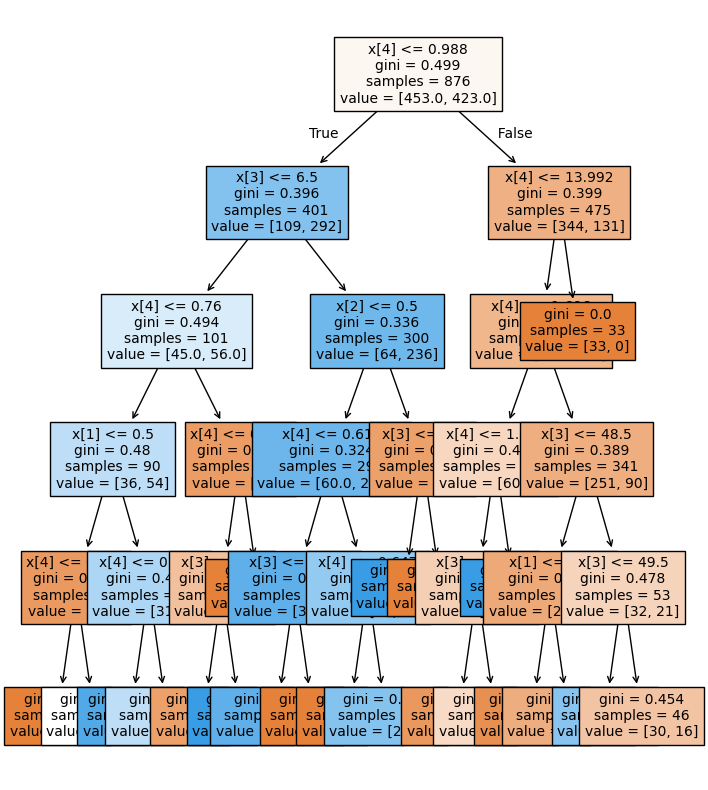

In [71]:
plt.figure(figsize = (8,10),)  # To see the text clearly in the chart
plot_tree(decision_tree = dt_model,fontsize = 10,filled = True)
plt.show()

#  Model Testing

## Training Data

In [49]:
Y_pred_train_dt= dt_model.predict(X_train)
Y_pred_train_dt

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

## Testing Data

In [50]:
Y_pred_test_dt= dt_model.predict(X_test)
Y_pred_test_dt

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0])

# Model Evaluation

## Training Data Evaluation Metrics

In [51]:
print(classification_report(y_true = Y_train, y_pred = Y_pred_train_dt))

              precision    recall  f1-score   support

           0       0.75      0.81      0.77       453
           1       0.77      0.71      0.74       423

    accuracy                           0.76       876
   macro avg       0.76      0.76      0.76       876
weighted avg       0.76      0.76      0.76       876



In [54]:
print(confusion_matrix(y_true = Y_train, y_pred = Y_pred_train_dt))

[[365  88]
 [124 299]]


In [55]:
accuracy_score(Y_train,Y_pred_train_dt)

0.7579908675799086

0.7562976531554804


Text(0, 0.5, 'True Positive Rate')

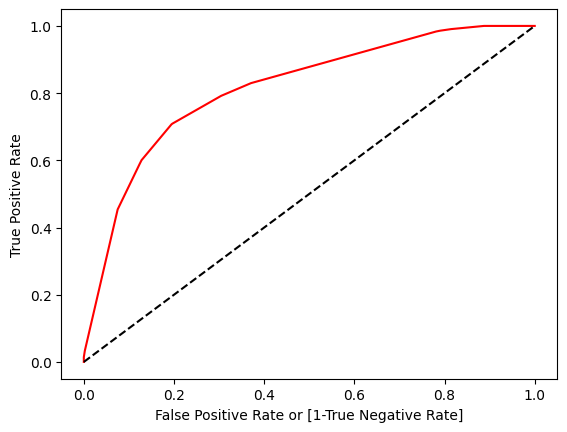

In [60]:
fpr,tpr,thresholds = roc_curve(y_true = Y_train,y_score = dt_model.predict_proba(X = X_train)[:,1])

auc = roc_auc_score(y_true = Y_train,y_score = Y_pred_train_dt)
print(auc)

from matplotlib import pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'DT model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

## Test Data Evaluation Metrics

In [56]:
print(classification_report(y_true = Y_test, y_pred = Y_pred_test_dt))

              precision    recall  f1-score   support

           0       0.76      0.75      0.76       125
           1       0.68      0.68      0.68        95

    accuracy                           0.72       220
   macro avg       0.72      0.72      0.72       220
weighted avg       0.72      0.72      0.72       220



In [57]:
print(confusion_matrix(y_true = Y_test, y_pred = Y_pred_test_dt))

[[94 31]
 [30 65]]


In [58]:
accuracy_score(Y_test,Y_pred_test_dt)

0.7227272727272728

0.7181052631578948


Text(0, 0.5, 'True Positive Rate')

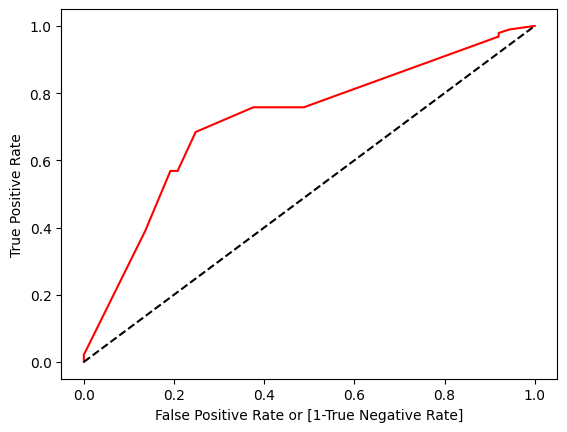

In [59]:
fpr,tpr,thresholds = roc_curve(y_true = Y_test,y_score = dt_model.predict_proba(X = X_test)[:,1])

auc = roc_auc_score(y_true = Y_test,y_score = Y_pred_test_dt)
print(auc)

from matplotlib import pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'DT model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

#### Training Accuracy - 75%
#### Test Accuracy - 72%

  - So now, we Generalized the Model(Low Bias and Low Variance) from overfitting problem.
  - So,we always try to **Tradeoff**(balance) maintained between **Bias and Variance**.

# -------Random Forest----------

# Model Training

In [117]:
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,VotingClassifier

In [92]:
rf_classifier = RandomForestClassifier( n_estimators=100,max_depth= 5) # if you didnt limit the depth....you will end up with OverFitting
rf_classifier.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Grid Search CV(Cross Validation)

In [104]:
grid_search = GridSearchCV(estimator = rf_classifier,param_grid = {"max_depth":[5,6,7,8,9,10], 
                                                                   "criterion":['gini','entropy'],
                                                                   "n_estimators":[50,75,100,150]})
grid_search.fit(X,Y)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 50}
0.7335533416355334


In [ ]:
# If you want to fit these best methods into model to get best result you can do that also

# Model Testing

## Training Data

In [93]:
Y_pred_train_dt= rf_classifier.predict(X_train)
Y_pred_train_dt

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

## Test Data

In [94]:
Y_pred_test_dt= rf_classifier.predict(X_test)
Y_pred_test_dt

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0])

# Model Evaluation

In [95]:
print(classification_report(y_true = Y_train, y_pred = Y_pred_train_dt))

              precision    recall  f1-score   support

           0       0.74      0.79      0.77       453
           1       0.76      0.70      0.73       423

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



In [96]:
print(confusion_matrix(y_true = Y_train, y_pred = Y_pred_train_dt))

[[360  93]
 [125 298]]


In [97]:
accuracy_score(Y_train,Y_pred_train_dt)

0.7511415525114156

0.7495968562616442


Text(0, 0.5, 'True Positive Rate')

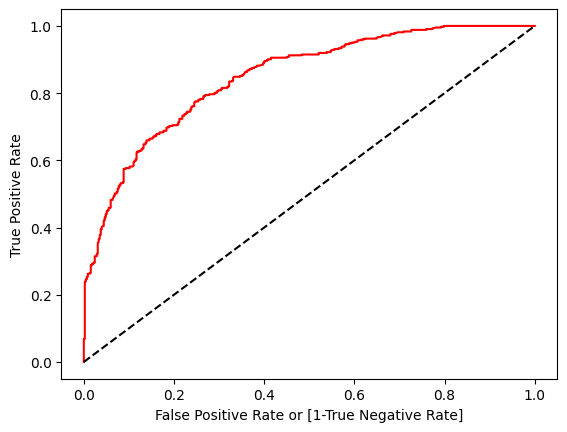

In [101]:
fpr,tpr,thresholds = roc_curve(y_true = Y_train,y_score = rf_classifier.predict_proba(X = X_train)[:,1])

auc = roc_auc_score(y_true = Y_train,y_score = Y_pred_train_dt)
print(auc)

from matplotlib import pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'DT model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

## Test Data Evaluation Metrics

In [98]:
print(classification_report(y_true = Y_test, y_pred = Y_pred_test_dt))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75       125
           1       0.67      0.67      0.67        95

    accuracy                           0.72       220
   macro avg       0.71      0.71      0.71       220
weighted avg       0.72      0.72      0.72       220



In [99]:
print(confusion_matrix(y_true = Y_test, y_pred = Y_pred_test_dt))

[[94 31]
 [31 64]]


In [100]:
accuracy_score(Y_test,Y_pred_test_dt)

0.7181818181818181

0.7128421052631578


Text(0, 0.5, 'True Positive Rate')

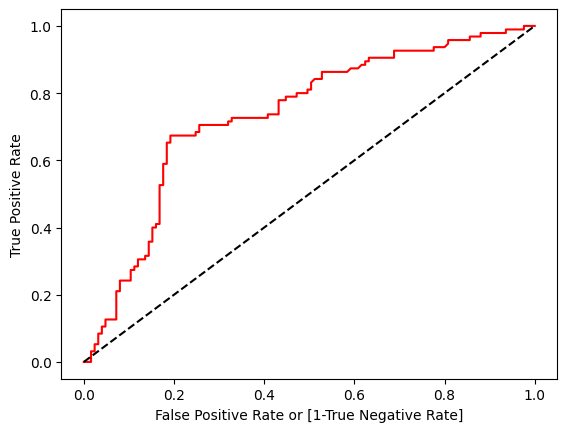

In [102]:
fpr,tpr,thresholds = roc_curve(y_true = Y_test,y_score = rf_classifier.predict_proba(X = X_test)[:,1])

auc = roc_auc_score(y_true = Y_test,y_score = Y_pred_test_dt)
print(auc)

from matplotlib import pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'DT model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

# --------Ada Boosting---------

# Model Training

In [106]:
ab_classifier = AdaBoostClassifier( n_estimators=50) # if you didnt limit the depth....you will end up with OverFitting
ab_classifier.fit(X_train,Y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


# Model Testing 

## Training Data

In [107]:
Y_pred_train_dt= ab_classifier.predict(X_train)
Y_pred_train_dt

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

## Test Data

In [108]:
Y_pred_test_dt= ab_classifier.predict(X_test)
Y_pred_test_dt

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0])

# Model Evaluation 

## Training Data Evaluation Metrics

In [109]:
print(classification_report(y_true = Y_train, y_pred = Y_pred_train_dt))

              precision    recall  f1-score   support

           0       0.72      0.76      0.74       453
           1       0.73      0.69      0.71       423

    accuracy                           0.73       876
   macro avg       0.73      0.72      0.73       876
weighted avg       0.73      0.73      0.73       876



In [110]:
print(confusion_matrix(y_true = Y_train, y_pred = Y_pred_train_dt))

[[344 109]
 [131 292]]


In [111]:
accuracy_score(Y_train,Y_pred_train_dt)

0.726027397260274

0.7248446135299735


Text(0, 0.5, 'True Positive Rate')

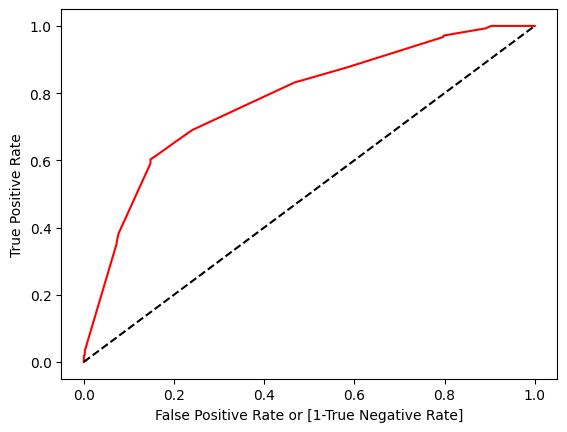

In [112]:
fpr,tpr,thresholds = roc_curve(y_true = Y_train,y_score = ab_classifier.predict_proba(X = X_train)[:,1])

auc = roc_auc_score(y_true = Y_train,y_score = Y_pred_train_dt)
print(auc)

from matplotlib import pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'DT model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

## Test Data Evaluation Metrics

In [113]:
print(classification_report(y_true = Y_test, y_pred = Y_pred_test_dt))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       125
           1       0.68      0.68      0.68        95

    accuracy                           0.73       220
   macro avg       0.72      0.72      0.72       220
weighted avg       0.73      0.73      0.73       220



In [114]:
print(confusion_matrix(y_true = Y_test, y_pred = Y_pred_test_dt))

[[95 30]
 [30 65]]


In [115]:
accuracy_score(Y_test,Y_pred_test_dt)

0.7272727272727273

0.7221052631578948


Text(0, 0.5, 'True Positive Rate')

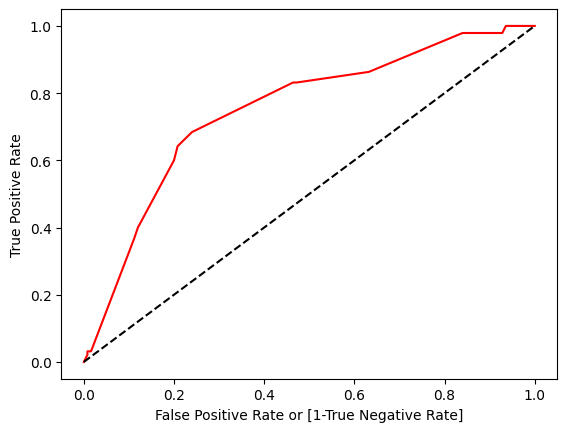

In [116]:
fpr,tpr,thresholds = roc_curve(y_true = Y_test,y_score = ab_classifier.predict_proba(X = X_test)[:,1])

auc = roc_auc_score(y_true = Y_test,y_score = Y_pred_test_dt)
print(auc)

from matplotlib import pyplot as plt
plt.plot(fpr,tpr,color = 'red', label = 'DT model (area=%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel('True Positive Rate')

# ---------Stacking Technique-----------

In [118]:
from sklearn.neighbors import KNeighborsClassifier

In [122]:
logistic_classifier = LogisticRegression()
dt_classifier = DecisionTreeClassifier()
knn_classifier = KNeighborsClassifier()
voting_classifier = VotingClassifier(estimators = [("logistic_model",logistic_classifier),
                                              ("dt_model",dt_classifier),
                                              ("knn_model",knn_classifier)])

voting_classifier.fit(X,Y)

y_pred = voting_classifier.predict(X)

accuracy_score(Y,y_pred)

0.8394160583941606

In [123]:
# You can also split the data and perform the all evaluation techniques

In [125]:
# But this technique is NOT Advisable.because if it is any error,we coldnt be analyse all the algorithms and find which causes the issues